In [ ]:
from transformers import AutoModel, AutoTokenizer
from conllu import parse_incr

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from tqdm import tqdm
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr
from scipy.sparse.csgraph import minimum_spanning_tree
from Probe_analysis import StructuralProbeAnalyzer
from transformers import AutoModel, AutoTokenizer
from logitlense import PosLogitLensAnalyzer
import pandas as pd
from transformers import AutoModelForMaskedLM, AutoTokenizer
import sys
sys.path.insert(0, "/mlama")  
from dataset.reader import MLama
import torch.nn.functional as F
from visualizer import Visualizer

# mBERT-ZH

In [ ]:
viz = Visualizer()

subjects = ["COL", "GFW", "JUS", "KOP", "TYE", "ZEK"]

df_avg_mbert_zh_zh = viz.average_logit_lens_results(
    subjects=subjects,
    family_name="mBERT",
    prompt_language="zh_zh",      
)

df_avg_mbert_zh_en = viz.average_logit_lens_results(
    subjects=subjects,
    family_name="mBERT",
    prompt_language="zh_en",     
)

Loaded: logitlense_results/subject_COL/logitlens_mBERT_zh_zh_COL.pkl
Loaded: logitlense_results/subject_GFW/logitlens_mBERT_zh_zh_GFW.pkl
Loaded: logitlense_results/subject_JUS/logitlens_mBERT_zh_zh_JUS.pkl
Loaded: logitlense_results/subject_KOP/logitlens_mBERT_zh_zh_KOP.pkl
Loaded: logitlense_results/subject_TYE/logitlens_mBERT_zh_zh_TYE.pkl
Loaded: logitlense_results/subject_ZEK/logitlens_mBERT_zh_zh_ZEK.pkl
Loaded: logitlense_results/subject_COL/logitlens_mBERT_zh_en_COL.pkl
Loaded: logitlense_results/subject_GFW/logitlens_mBERT_zh_en_GFW.pkl
Loaded: logitlense_results/subject_JUS/logitlens_mBERT_zh_en_JUS.pkl
Loaded: logitlense_results/subject_KOP/logitlens_mBERT_zh_en_KOP.pkl
Loaded: logitlense_results/subject_TYE/logitlens_mBERT_zh_en_TYE.pkl
Loaded: logitlense_results/subject_ZEK/logitlens_mBERT_zh_en_ZEK.pkl


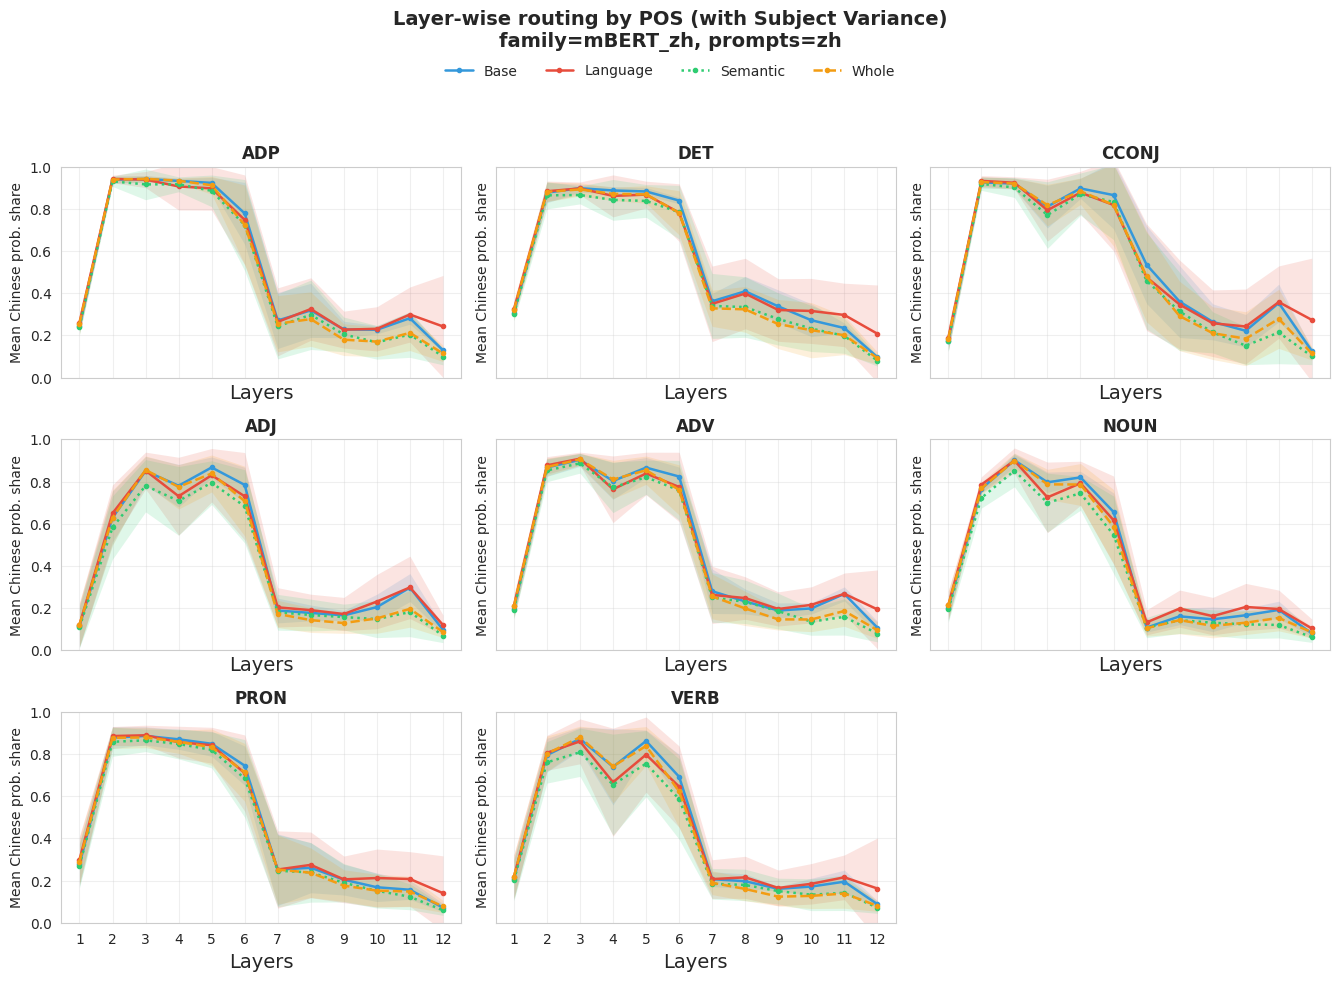

In [3]:
viz.plot_layerwise_pos_grid_from_file(
    results_df=df_avg_mbert_zh_zh,
    family_name="mBERT_zh",
    language="zh",
    stat="share",
    which_share="zh",
    base_model_name="Base",
    pos_order=["ADP", "DET", "CCONJ", "ADJ", "ADV", "NOUN", "PRON", "VERB"],
)

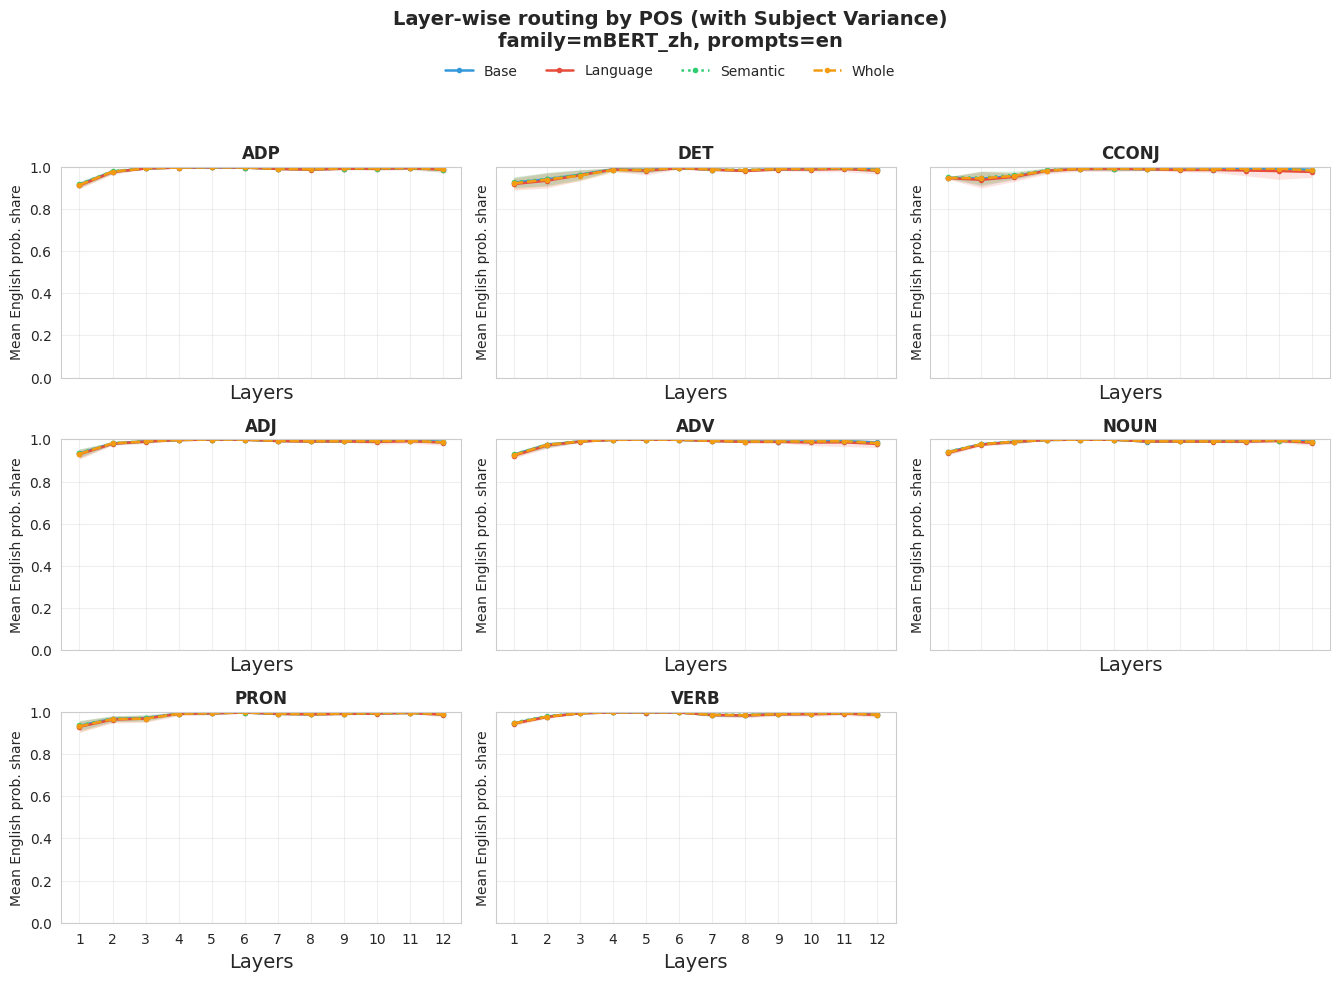

In [4]:
viz.plot_layerwise_pos_grid_from_file(
    results_df=df_avg_mbert_zh_en,
    family_name="mBERT_zh",
    language="en",
    stat="share",
    which_share="en",
    base_model_name="Base",
    pos_order=["ADP", "DET", "CCONJ", "ADJ", "ADV", "NOUN", "PRON", "VERB"],
)

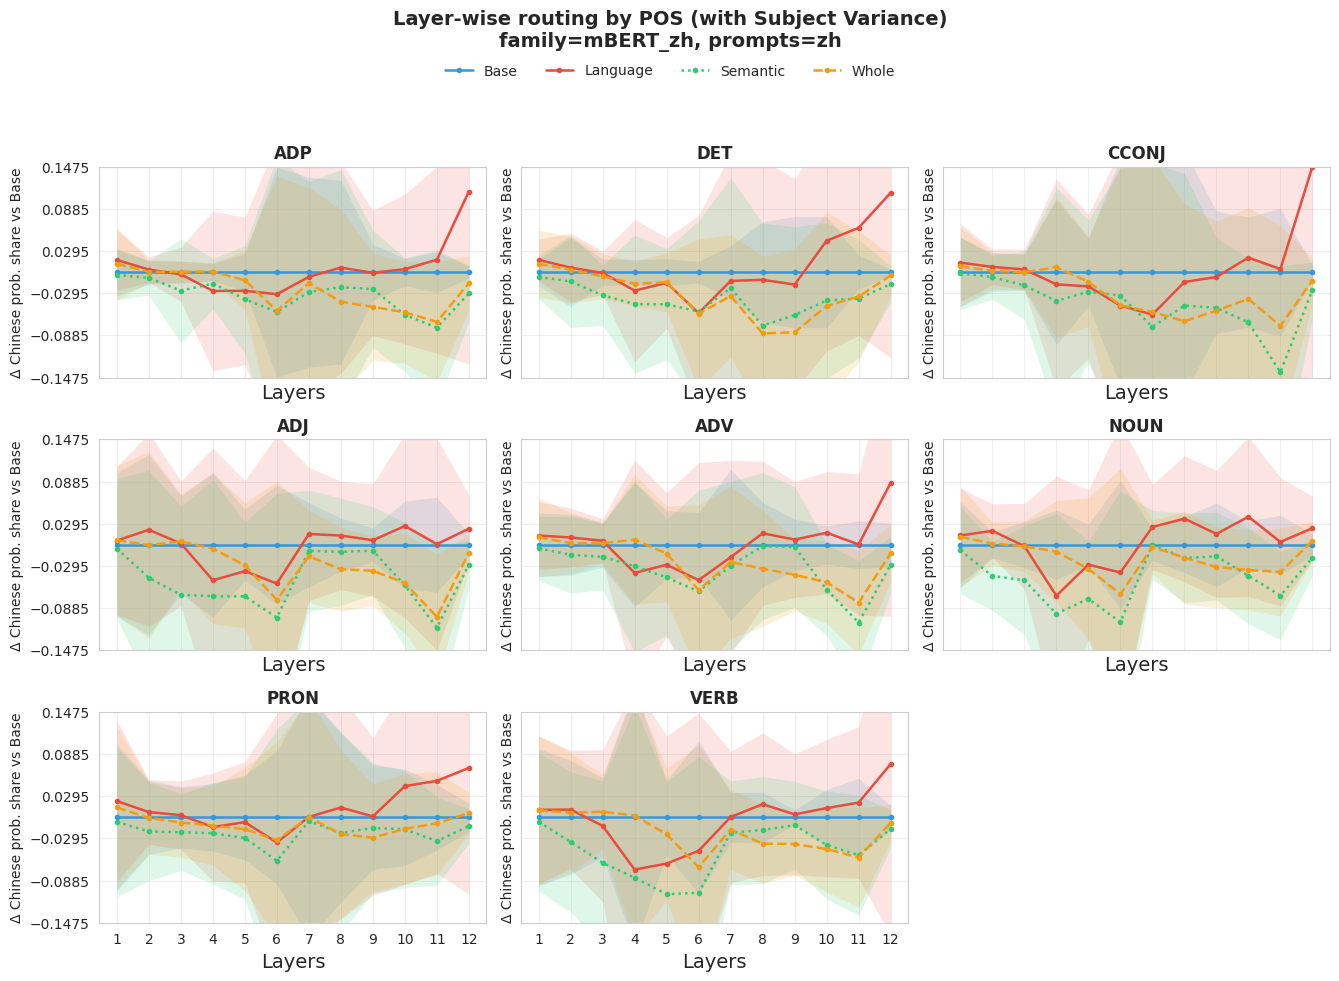

In [5]:
viz.plot_layerwise_pos_grid_from_file(
    results_df=df_avg_mbert_zh_zh,
    family_name="mBERT_zh",
    language="zh",
    stat="delta_vs_base",
    which_share="zh",
    base_model_name="Base",
    pos_order=["ADP", "DET", "CCONJ", "ADJ", "ADV", "NOUN", "PRON", "VERB"],
)

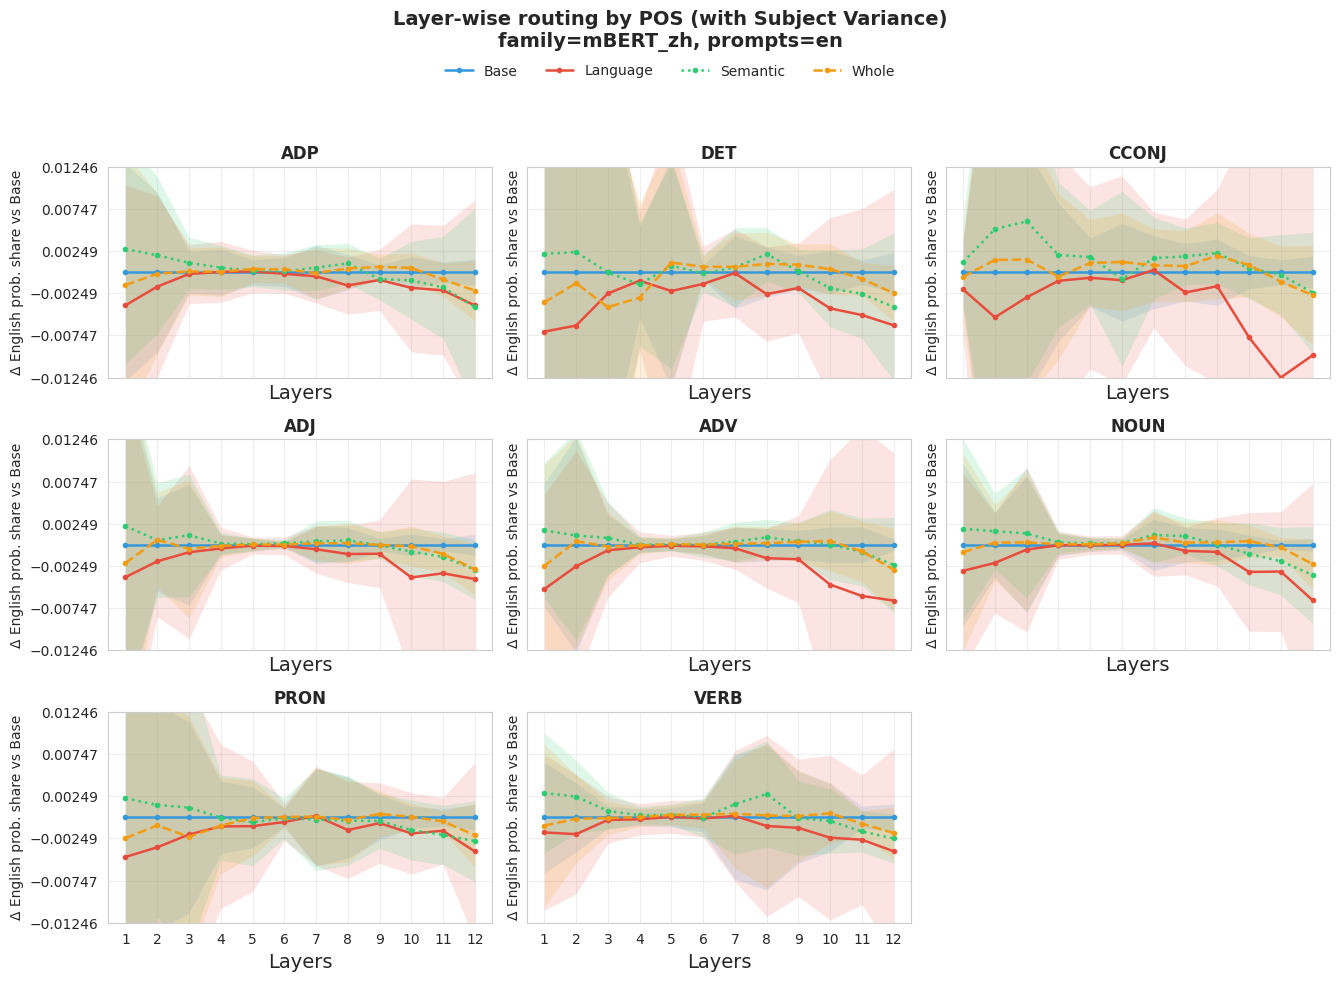

In [6]:
viz.plot_layerwise_pos_grid_from_file(
    results_df=df_avg_mbert_zh_en,
    family_name="mBERT_zh",
    language="en",
    stat="delta_vs_base",
    which_share="en",
    base_model_name="Base",
    pos_order=["ADP", "DET", "CCONJ", "ADJ", "ADV", "NOUN", "PRON", "VERB"],
)

Loaded: logitlense_results/subject_COL/logitlens_mBERT_zh_zh_COL.pkl
Loaded: logitlense_results/subject_GFW/logitlens_mBERT_zh_zh_GFW.pkl
Loaded: logitlense_results/subject_JUS/logitlens_mBERT_zh_zh_JUS.pkl
Loaded: logitlense_results/subject_KOP/logitlens_mBERT_zh_zh_KOP.pkl
Loaded: logitlense_results/subject_TYE/logitlens_mBERT_zh_zh_TYE.pkl
Loaded: logitlense_results/subject_ZEK/logitlens_mBERT_zh_zh_ZEK.pkl


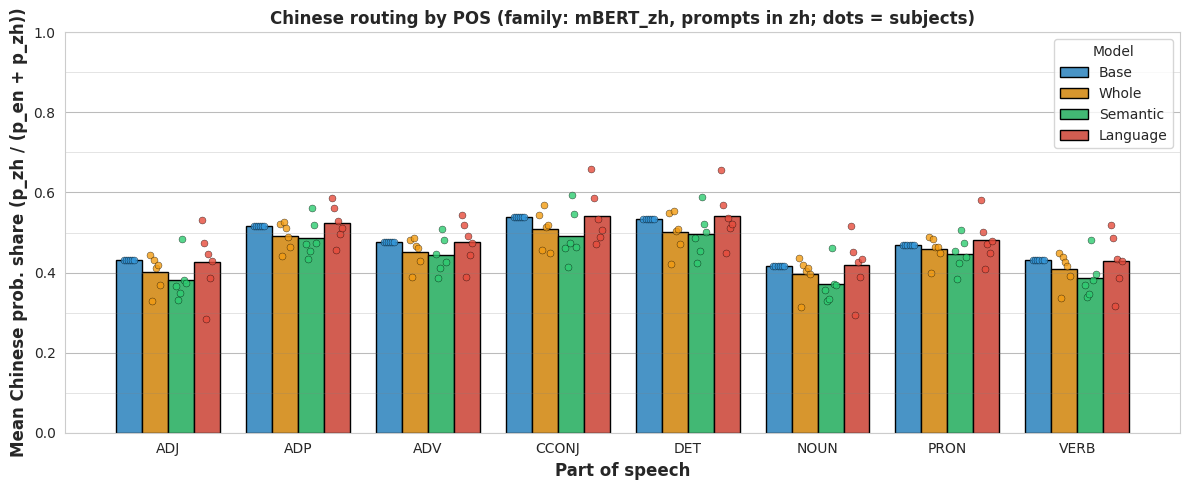

In [ ]:
viz.plot_routing_by_pos_subject_dots(
    subjects=subjects,
    family_name="mBERT_zh",       
    prompt_language="zh",       
    which_share="zh"         
)


Loaded: logitlense_results/subject_COL/logitlens_mBERT_zh_en_COL.pkl
Loaded: logitlense_results/subject_GFW/logitlens_mBERT_zh_en_GFW.pkl
Loaded: logitlense_results/subject_JUS/logitlens_mBERT_zh_en_JUS.pkl
Loaded: logitlense_results/subject_KOP/logitlens_mBERT_zh_en_KOP.pkl
Loaded: logitlense_results/subject_TYE/logitlens_mBERT_zh_en_TYE.pkl
Loaded: logitlense_results/subject_ZEK/logitlens_mBERT_zh_en_ZEK.pkl


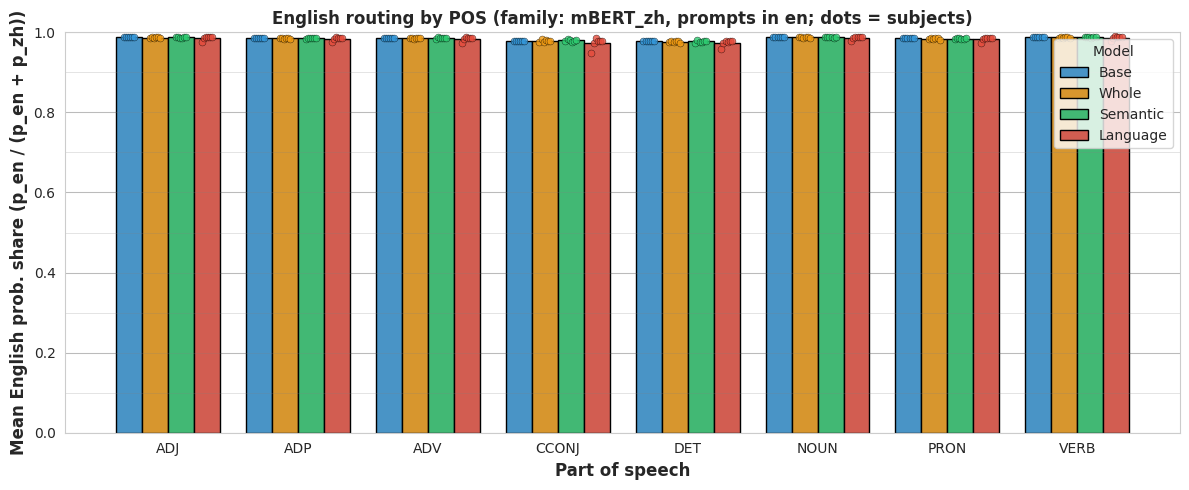

In [ ]:
viz.plot_routing_by_pos_subject_dots(
    subjects=subjects,
    family_name="mBERT_zh",        
    prompt_language="en",     
    which_share="en"        
)


# mBERT-EN

In [ ]:
viz = Visualizer()

subjects = ["COL", "GFW", "JUS", "KOP", "TYE", "ZEK"]

df_avg_mbert_en_zh = viz.average_logit_lens_results(
    subjects=subjects,
    family_name="mBERT",
    prompt_language="en_zh",      
)

df_avg_mbert_en_en = viz.average_logit_lens_results(
    subjects=subjects,
    family_name="mBERT",
    prompt_language="en_en",      
)

Loaded: logitlense_results/subject_COL/logitlens_mBERT_en_zh_COL.pkl
Loaded: logitlense_results/subject_GFW/logitlens_mBERT_en_zh_GFW.pkl
Loaded: logitlense_results/subject_JUS/logitlens_mBERT_en_zh_JUS.pkl
Loaded: logitlense_results/subject_KOP/logitlens_mBERT_en_zh_KOP.pkl
Loaded: logitlense_results/subject_TYE/logitlens_mBERT_en_zh_TYE.pkl
Loaded: logitlense_results/subject_ZEK/logitlens_mBERT_en_zh_ZEK.pkl
Loaded: logitlense_results/subject_COL/logitlens_mBERT_en_en_COL.pkl
Loaded: logitlense_results/subject_GFW/logitlens_mBERT_en_en_GFW.pkl
Loaded: logitlense_results/subject_JUS/logitlens_mBERT_en_en_JUS.pkl
Loaded: logitlense_results/subject_KOP/logitlens_mBERT_en_en_KOP.pkl
Loaded: logitlense_results/subject_TYE/logitlens_mBERT_en_en_TYE.pkl
Loaded: logitlense_results/subject_ZEK/logitlens_mBERT_en_en_ZEK.pkl


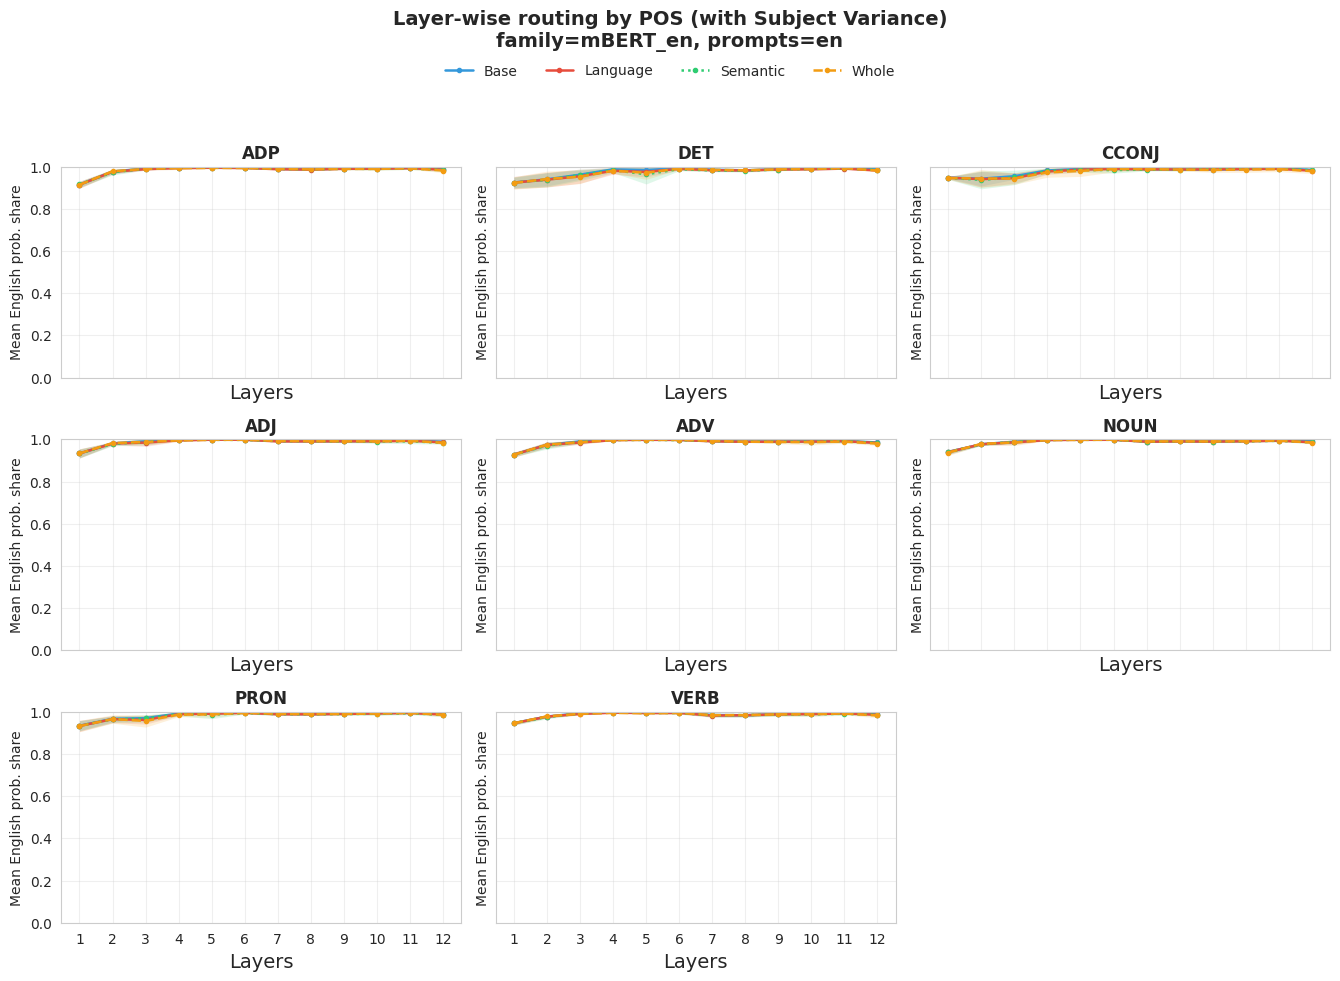

In [10]:
viz.plot_layerwise_pos_grid_from_file(
    results_df=df_avg_mbert_en_en,
    family_name="mBERT_en",
    language="en",
    stat="share",
    which_share="en",
    base_model_name="Base",
    pos_order=["ADP", "DET", "CCONJ", "ADJ", "ADV", "NOUN", "PRON", "VERB"],
)

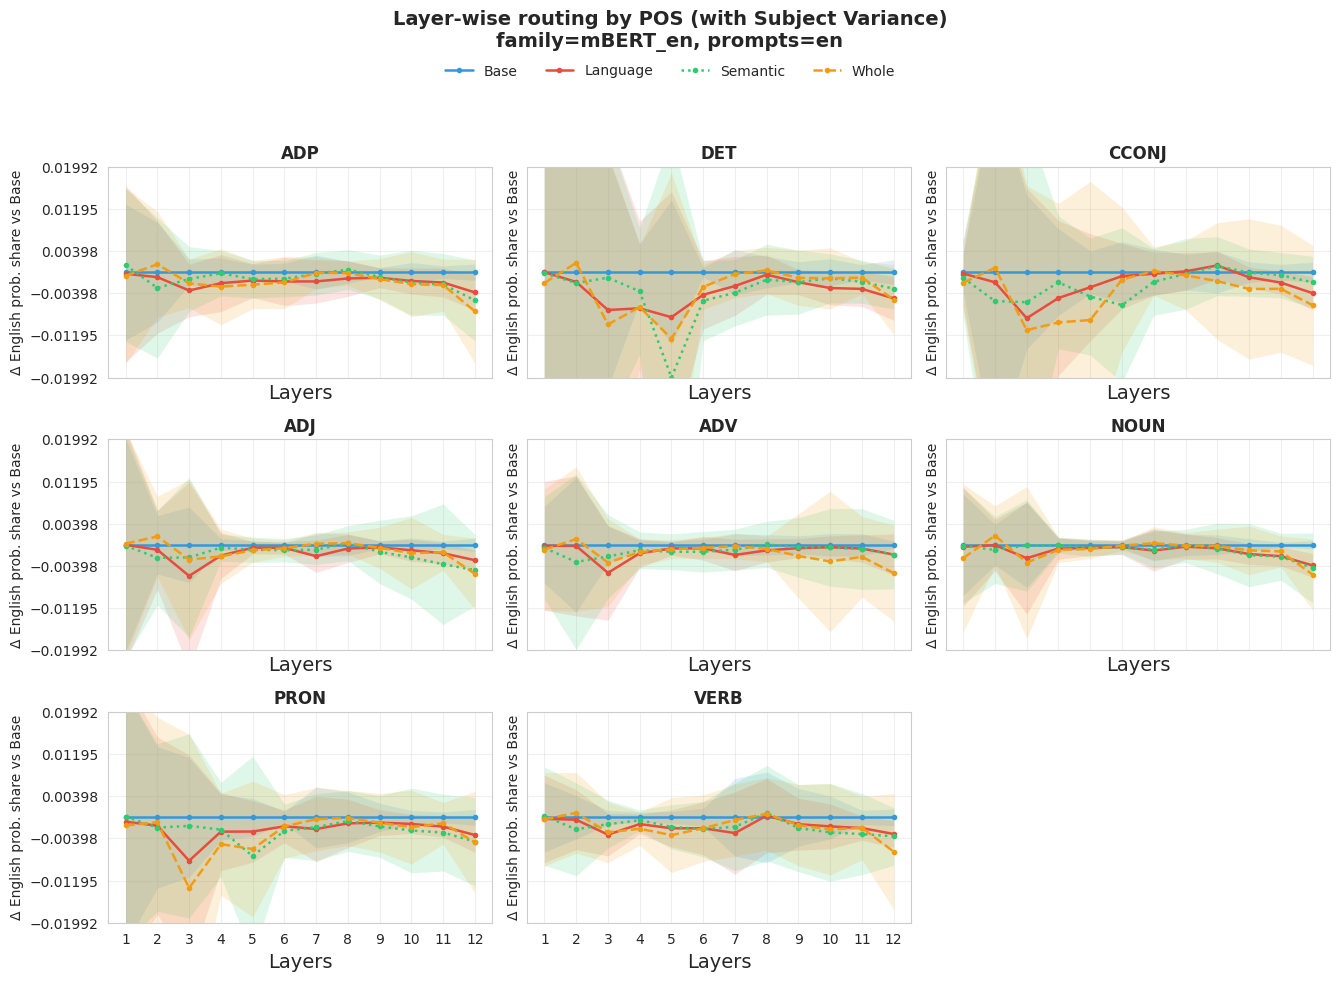

In [11]:
viz.plot_layerwise_pos_grid_from_file(
    results_df=df_avg_mbert_en_en,
    family_name="mBERT_en",
    language="en",
    stat="delta_vs_base",
    which_share="en",
    base_model_name="Base",
    pos_order=["ADP", "DET", "CCONJ", "ADJ", "ADV", "NOUN", "PRON", "VERB"],
)

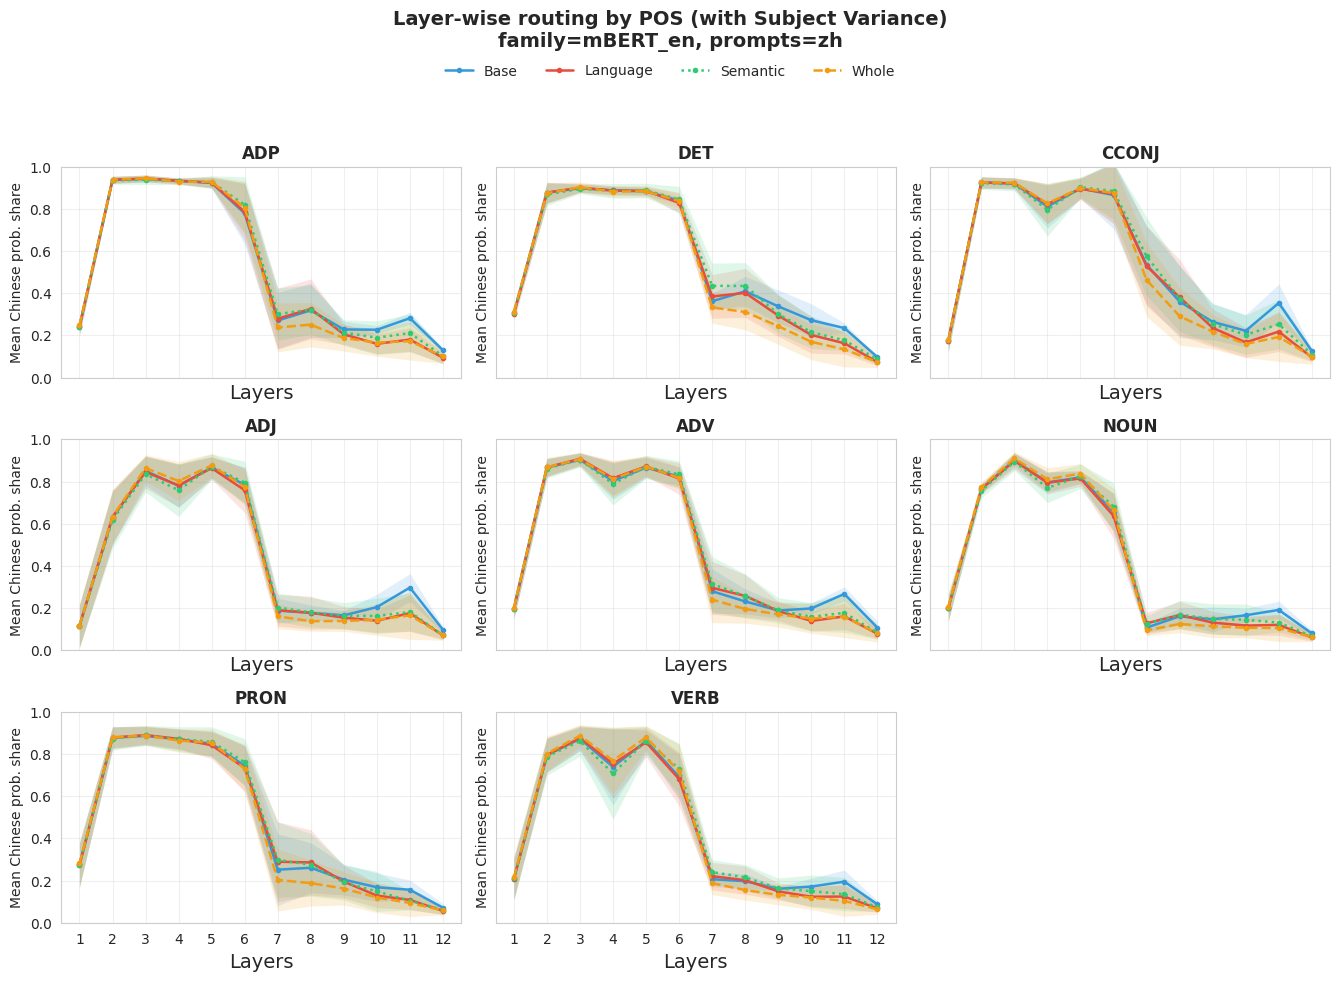

In [12]:
viz.plot_layerwise_pos_grid_from_file(
    results_df=df_avg_mbert_en_zh,
    family_name="mBERT_en",
    language="zh",
    stat="share",
    which_share="zh",
    base_model_name="Base",
    pos_order=["ADP", "DET", "CCONJ", "ADJ", "ADV", "NOUN", "PRON", "VERB"],
)

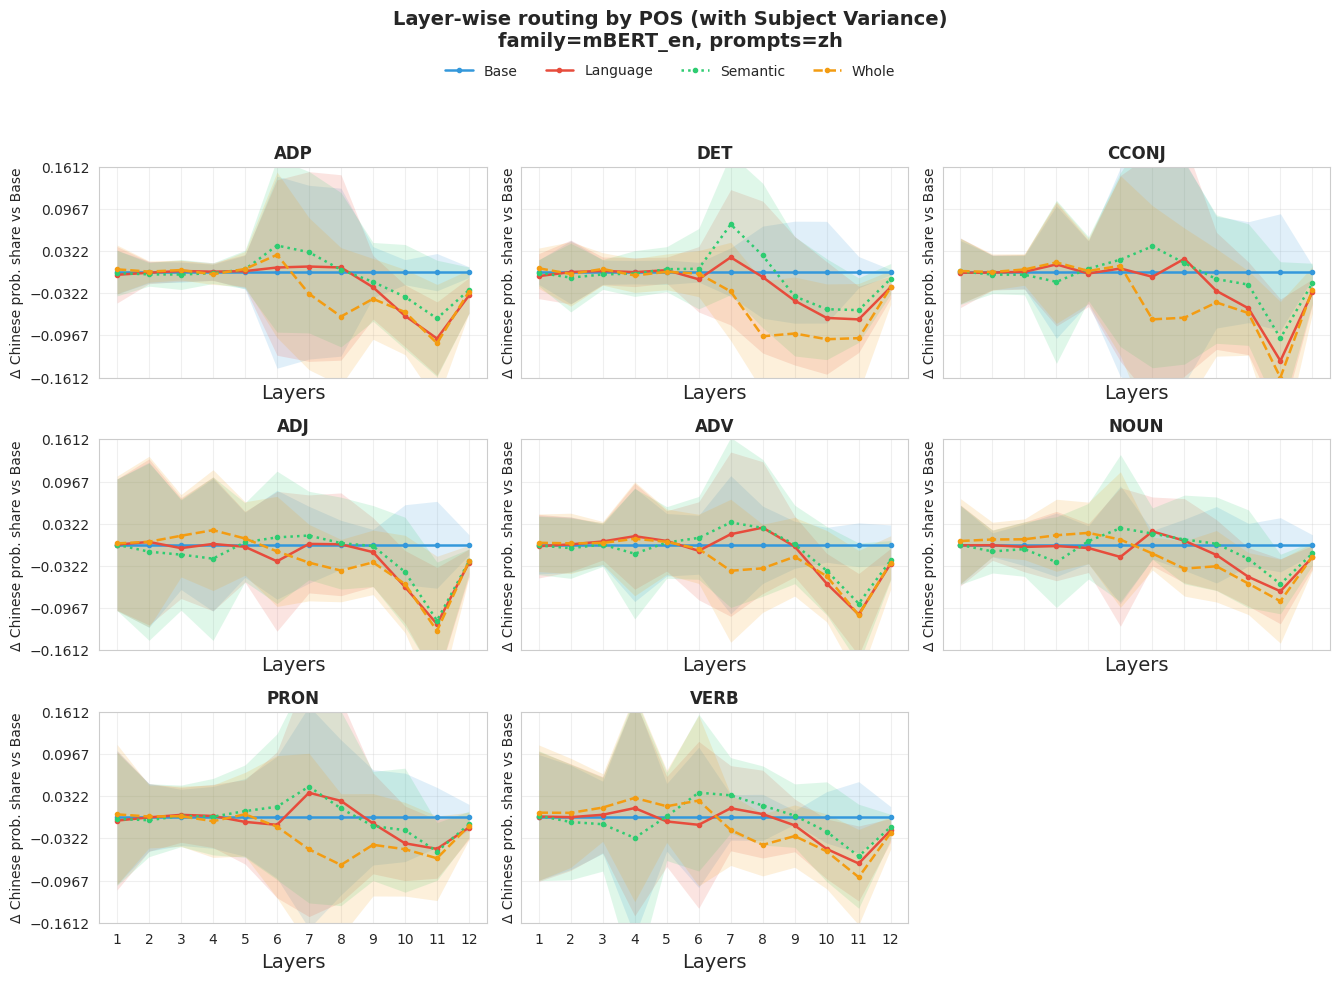

In [13]:
viz.plot_layerwise_pos_grid_from_file(
    results_df=df_avg_mbert_en_zh,
    family_name="mBERT_en",
    language="zh",
    stat="delta_vs_base",
    which_share="zh",
    base_model_name="Base",
    pos_order=["ADP", "DET", "CCONJ", "ADJ", "ADV", "NOUN", "PRON", "VERB"],
)

Loaded: logitlense_results/subject_COL/logitlens_mBERT_en_en_COL.pkl
Loaded: logitlense_results/subject_GFW/logitlens_mBERT_en_en_GFW.pkl
Loaded: logitlense_results/subject_JUS/logitlens_mBERT_en_en_JUS.pkl
Loaded: logitlense_results/subject_KOP/logitlens_mBERT_en_en_KOP.pkl
Loaded: logitlense_results/subject_TYE/logitlens_mBERT_en_en_TYE.pkl
Loaded: logitlense_results/subject_ZEK/logitlens_mBERT_en_en_ZEK.pkl


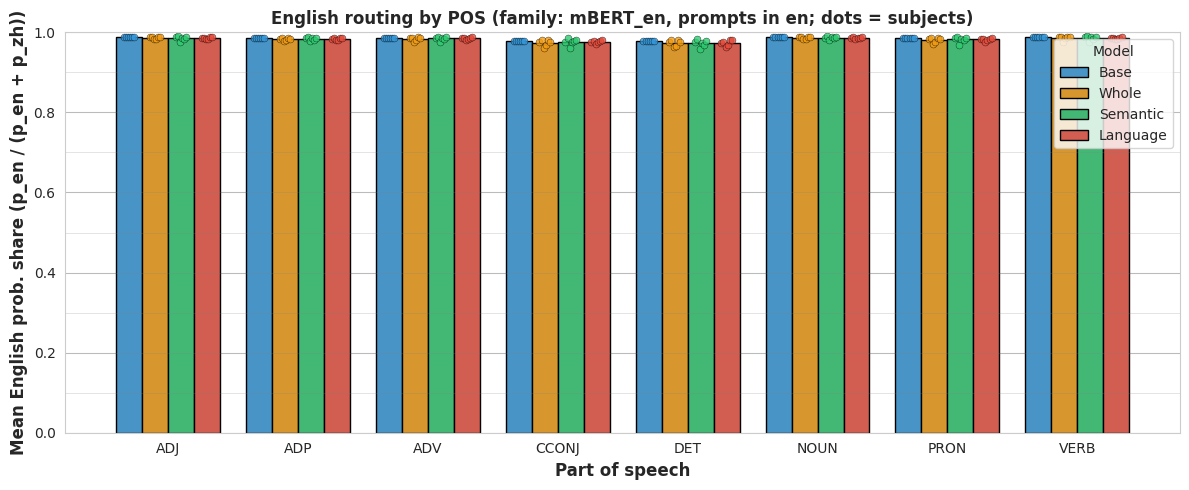

In [ ]:
viz.plot_routing_by_pos_subject_dots(
    subjects=subjects,
    family_name="mBERT_en",        
    prompt_language="en",       
    which_share="en"        
)


Loaded: logitlense_results/subject_COL/logitlens_mBERT_en_zh_COL.pkl
Loaded: logitlense_results/subject_GFW/logitlens_mBERT_en_zh_GFW.pkl
Loaded: logitlense_results/subject_JUS/logitlens_mBERT_en_zh_JUS.pkl
Loaded: logitlense_results/subject_KOP/logitlens_mBERT_en_zh_KOP.pkl
Loaded: logitlense_results/subject_TYE/logitlens_mBERT_en_zh_TYE.pkl
Loaded: logitlense_results/subject_ZEK/logitlens_mBERT_en_zh_ZEK.pkl


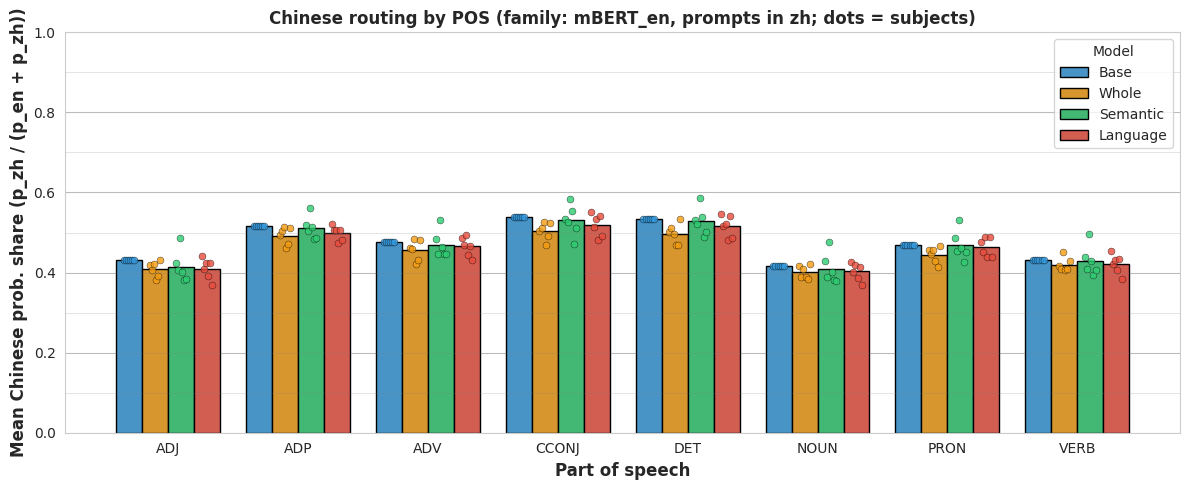

In [ ]:
viz.plot_routing_by_pos_subject_dots(
    subjects=subjects,
    family_name="mBERT_en",       
    prompt_language="zh",      
    which_share="zh"        
)
